In [85]:
from datasets import load_from_disk
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [28]:
vnlegal_corpus = load_from_disk("./raw/vnlegal_corpus")
vnlegal_qa = load_from_disk("./raw/vnlegal_qa")
vnlegal_corpus[0], len(vnlegal_corpus), vnlegal_qa[0], len(vnlegal_qa)

({'passage_id': 'luat_ia_chat_va_khoang_san_cua_quoc_hoi_so_54_2024_qh15_dieu_5_8a08edb9',
  'doc_name': 'Luật Địa chất và Khoáng sản của Quốc hội, số 54/2024/QH15',
  'article_content': 'Điều 5. Nguyên tắc hội nhập và hợp tác quốc tế về địa chất, khoáng sản\n\n1. Hội nhập và hợp tác quốc tế trong nghiên cứu, điều tra cơ bản địa chất, điều tra địa chất về khoáng sản, hoạt động khoáng sản, quản lý hoạt động khoáng sản phải đặt trong tổng thể chiến lược phát triển kinh tế - xã hội của đất nước trong từng thời kỳ; chiến lược địa chất, khoáng sản và công nghiệp khai khoáng; tuân thủ Hiến pháp, pháp luật Việt Nam, Hiến chương Liên hợp quốc, điều ước quốc tế mà nước Cộng hòa xã hội chủ nghĩa Việt Nam là thành viên, bảo đảm phù hợp với đường lối và chính sách đối ngoại của Việt Nam; bảo đảm nguyên tắc hợp tác bình đẳng, cùng có lợi trên cơ sở tôn trọng độc lập, chủ quyền và toàn vẹn lãnh thổ, không can thiệp vào công việc nội bộ của nhau.\n\n2. Tranh chấp quốc tế về địa chất, khoáng sản được 

In [29]:
corpus_df = vnlegal_corpus.to_pandas()
qa_df = vnlegal_qa.to_pandas()

## Sanity check

In [30]:
# Check null values in corpus
null_counts = corpus_df.isnull().sum()
print("Null value counts in VNLegal Corpus:")
print(null_counts)

Null value counts in VNLegal Corpus:
passage_id         0
doc_name           0
article_content    0
macro_domain       0
dtype: int64


In [31]:
# Check null values in qa
null_counts_qa = qa_df.isnull().sum()
print("Null value counts in VNLegal QA:")
print(null_counts_qa)

Null value counts in VNLegal QA:
qa_id            0
passage_id       0
question         0
answer           0
question_type    0
difficulty       0
macro_domain     0
dtype: int64


In [ ]:
# Check duplication in corpus
print(corpus_df["passage_id"].duplicated().sum())
print(corpus_df["article_content"].duplicated().sum())
print(corpus_df[["doc_name", "article_content"]].duplicated().sum())

0
133
0


In [51]:
dup_articles = corpus_df[
    corpus_df["article_content"].duplicated(keep=False)
].sort_values("article_content")

dup_articles[["doc_name", "passage_id", "article_content"]].head(20)

,doc_name,passage_id,article_content
4033,"Luật Công chứng của Quốc hội, số 53/2014/QH13",luat_cong_chung_cua_quoc_hoi_so_53_2014_qh13_d...,Điều 1. Phạm vi điều chỉnh\n\nLuật này quy địn...
8494,"Luật Công chứng của Quốc hội, số 46/2024/QH15",luat_cong_chung_cua_quoc_hoi_so_46_2024_qh15_d...,Điều 1. Phạm vi điều chỉnh\n\nLuật này quy địn...
767,"Luật Đường bộ của Quốc hội, số 35/2024/QH15",luat_uong_bo_cua_quoc_hoi_so_35_2024_qh15_dieu...,Điều 1. Phạm vi điều chỉnh\n\nLuật này quy địn...
2001,Dự thảo Luật Đường bộ (T5/2024),du_thao_luat_uong_bo_t5_2024_dieu_1_25840281,Điều 1. Phạm vi điều chỉnh\n\nLuật này quy địn...
1602,Dự thảo Luật Giao thông đường bộ (sửa đổi) lần 1,du_thao_luat_giao_thong_uong_bo_sua_oi_lan_1_d...,Điều 1. Phạm vi điều chỉnh\n\nLuật này quy địn...
2090,Dự thảo Luật Giao thông đường bộ (sửa đổi) lần 3,du_thao_luat_giao_thong_uong_bo_sua_oi_lan_3_d...,Điều 1. Phạm vi điều chỉnh\n\nLuật này quy địn...
4395,Dự thảo Luật Cư trú lần 2,du_thao_luat_cu_tru_lan_2_dieu_1_b7ff8d38,Điều 1. Phạm vi điều chỉnh\n\nLuật này quy địn...
4603,Dự thảo Luật Cư trú lần 3,du_thao_luat_cu_tru_lan_3_dieu_1_b7ff8d38,Điều 1. Phạm vi điều chỉnh\n\nLuật này quy địn...
4669,"Luật Các tổ chức tín dụng của Quốc hội, số 32/...",luat_cac_to_chuc_tin_dung_cua_quoc_hoi_so_32_2...,Điều 1. Phạm vi điều chỉnh\n\nLuật này quy địn...
6137,Dự thảo Luật Các tổ chức tín dụng (sửa đổi),du_thao_luat_cac_to_chuc_tin_dung_sua_oi_dieu_...,Điều 1. Phạm vi điều chỉnh\n\nLuật này quy địn...


In [55]:
# check duplication in qa
print(qa_df["qa_id"].duplicated().sum())
print(qa_df["question"].duplicated().sum())
print(qa_df["answer"].duplicated().sum())
print(qa_df[["question", "answer"]].duplicated().sum())

0
15
7
2


In [58]:
dup_questions = qa_df[
    qa_df["question"].duplicated(keep=False)
].copy()

dup_full = dup_questions.merge(
    corpus_df[["passage_id", "doc_name", "article_content"]],
    on="passage_id",
    how="left"
)

print(len(dup_full))
dup_full[["doc_name", "article_content", "question", "answer"]].sort_values("question")

30


,doc_name,article_content,question,answer
26,"Luật Bảo hiểm xã hội của Quốc hội, số 41/2024/...","Điều 83. Hồ sơ, trình tự khám giám định mức su...","Cơ quan nào có trách nhiệm quy định về hồ sơ, ...",Theo Khoản 1 Điều 83 Luật Bảo hiểm xã hội số 4...
27,"Luật Bảo hiểm xã hội của Quốc hội, số 58/2014/...","Điều 117. Hồ sơ, trình tự khám giám định mức s...","Cơ quan nào có trách nhiệm quy định về hồ sơ, ...",Theo Khoản 1 Điều 117 của Luật Bảo hiểm xã hội...
18,"Luật Công nghiệp quốc phòng, an ninh và động v...",Điều 85. Hiệu lực thi hành\n\n1. Luật này có h...,"Luật Công nghiệp quốc phòng, an ninh và động v...",Theo Khoản 1 Điều 85 của Luật Công nghiệp quốc...
19,"Luật Công nghiệp quốc phòng, an ninh và động v...",Điều 86. Quy định chuyển tiếp\n\n1. Các gói th...,"Luật Công nghiệp quốc phòng, an ninh và động v...",Theo khoản 1 Điều 85 của Luật Công nghiệp quốc...
22,"Luật Trách nhiệm bồi thường của Nhà nước, số 3...",Điều 65. Hiệu lực thi hành\n\n1. Luật này có h...,Luật Trách nhiệm bồi thường của Nhà nước số 35...,Theo Khoản 1 Điều 65 của Luật Trách nhiệm bồi ...
23,"Luật Trách nhiệm bồi thường của Nhà nước, số 3...",Điều 67. Quy định chi tiết và hướng dẫn thi hà...,Luật Trách nhiệm bồi thường của Nhà nước số 35...,Theo Điều 65 của Luật Trách nhiệm bồi thường c...
24,"Luật sửa đổi, bổ sung một số điều của Luật Đấu...",Điều 2. Hiệu lực thi hành\n\nLuật này có hiệu ...,"Luật sửa đổi, bổ sung một số điều của Luật Đấu...","Theo Điều 2 của Luật sửa đổi, bổ sung một số đ..."
25,"Luật sửa đổi, bổ sung một số điều của Luật Đấu...",Điều 3. Quy định chuyển tiếp\n\n1. Trường hợp ...,"Luật sửa đổi, bổ sung một số điều của Luật Đấu...","Theo Điều 2 của Luật số 37/2024/QH15, Luật này..."
0,Luật Giao thông đường bộ số 23/2008/QH12 của Q...,Điều 10. Hệ thống báo hiệu đường bộ\n\n1. Hệ t...,"Theo Điều 10 của Luật Giao thông đường bộ, hệ ...","Dựa trên Khoản 1, Điều 10 của Luật Giao thông ..."
1,Luật của Quốc hội số 26/2001/QH10 về Giao thôn...,Điều 10. Hệ thống báo hiệu đường bộ\n\n1. Hệ t...,"Theo Điều 10 của Luật Giao thông đường bộ, hệ ...",Theo Khoản 1 Điều 10 của Luật Giao thông đường...


## Overview

### Corpus

/var/folders/8b/ktndfm5s68739w9cvkrwvnj00000gp/T/ipykernel_94371/2254913394.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=domain_counts.index, y=domain_counts.values, palette="viridis")


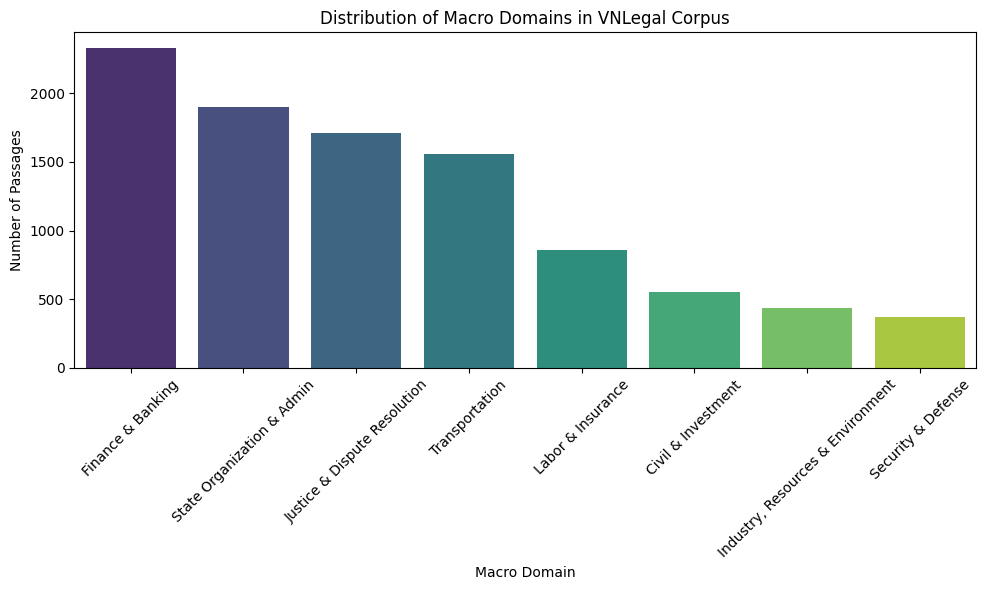

In [34]:
# Distribution of macro_domain
domain_counts = corpus_df["macro_domain"].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=domain_counts.index, y=domain_counts.values, palette="viridis")
plt.title("Distribution of Macro Domains in VNLegal Corpus")
plt.xlabel("Macro Domain")
plt.ylabel("Number of Passages")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Question

In [61]:
# Question distribution per passage
qa_df["passage_id"].value_counts().value_counts()
qa_df["question_count"] = qa_df.groupby("passage_id")["question"].transform("count")
qa_df["question_count"].value_counts()

question_count
3    29145
Name: count, dtype: int64

In [62]:
def get_diff_pattern(group):
    return tuple(sorted(group["difficulty"]))

pattern_df = (
    qa_df.groupby("passage_id")
    .apply(get_diff_pattern)
    .reset_index(name="pattern")
)

pattern_counts = pattern_df["pattern"].value_counts()

print(pattern_counts)

pattern
(easy, hard, medium)      9698
(easy, medium, medium)       7
(easy, easy, easy)           4
(easy, easy, medium)         3
(hard, medium, medium)       2
(easy, hard, hard)           1
Name: count, dtype: int64


#### Question type

In [35]:
question_type_counts = qa_df["question_type"].value_counts()
print(question_type_counts)

question_type
factual           9746
application       7522
interpretation    6439
analytical        5435
Thực tế              1
Giải thích           1
Ứng dụng             1
Name: count, dtype: int64


In [36]:
QUESTION_TYPE_MAP = {
    "thực tế": "factual",
    "giải thích": "interpretation",
    "ứng dụng": "application",
    "phân tích": "analytical",
}

qa_df["question_type"] = (
    qa_df["question_type"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace(QUESTION_TYPE_MAP)
)

print(qa_df["question_type"].value_counts())

question_type
factual           9747
application       7523
interpretation    6440
analytical        5435
Name: count, dtype: int64


/var/folders/8b/ktndfm5s68739w9cvkrwvnj00000gp/T/ipykernel_94371/1585346143.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=question_type_counts.index, y=question_type_counts.values, palette="magma")


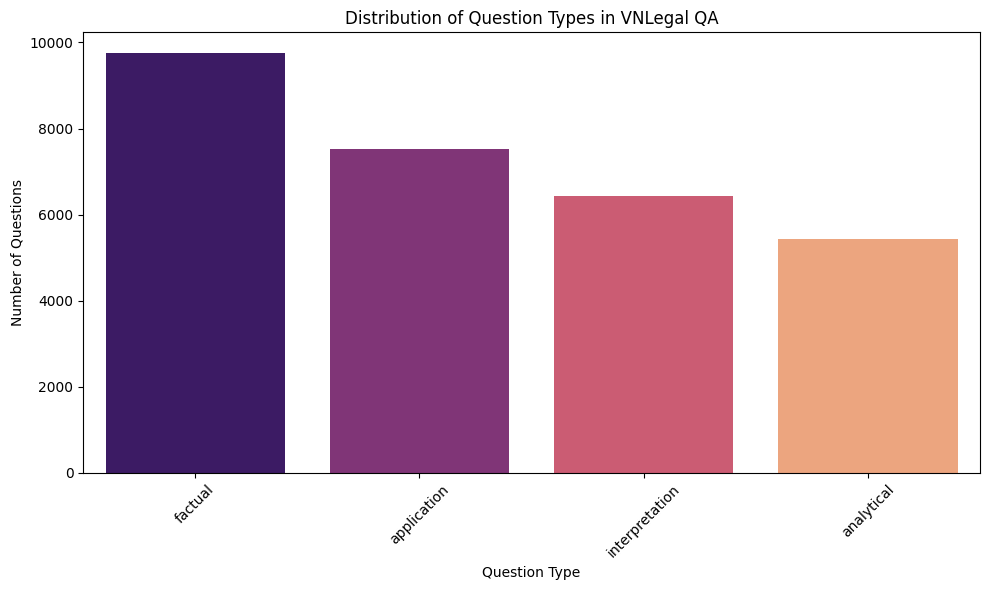

In [37]:
# Distribution of question types
question_type_counts = qa_df["question_type"].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=question_type_counts.index, y=question_type_counts.values, palette="magma")
plt.title("Distribution of Question Types in VNLegal QA")
plt.xlabel("Question Type")
plt.ylabel("Number of Questions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Difficulty

In [40]:
difficulty_counts = qa_df["difficulty"].value_counts()
print(difficulty_counts)

difficulty
easy          9723
medium        9718
hard          9701
Dễ               1
Trung bình       1
Khó              1
Name: count, dtype: int64


In [41]:
DIFFICULTY_MAP = {
    "dễ": "easy",
    "trung bình": "medium",
    "khó": "hard",
}

qa_df["difficulty"] = (
    qa_df["difficulty"]    .astype(str)
    .str.strip()
    .str.lower()
    .replace(DIFFICULTY_MAP)
)

/var/folders/8b/ktndfm5s68739w9cvkrwvnj00000gp/T/ipykernel_94371/2871641209.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=difficulty_counts.index, y=difficulty_counts.values, palette="coolwarm")


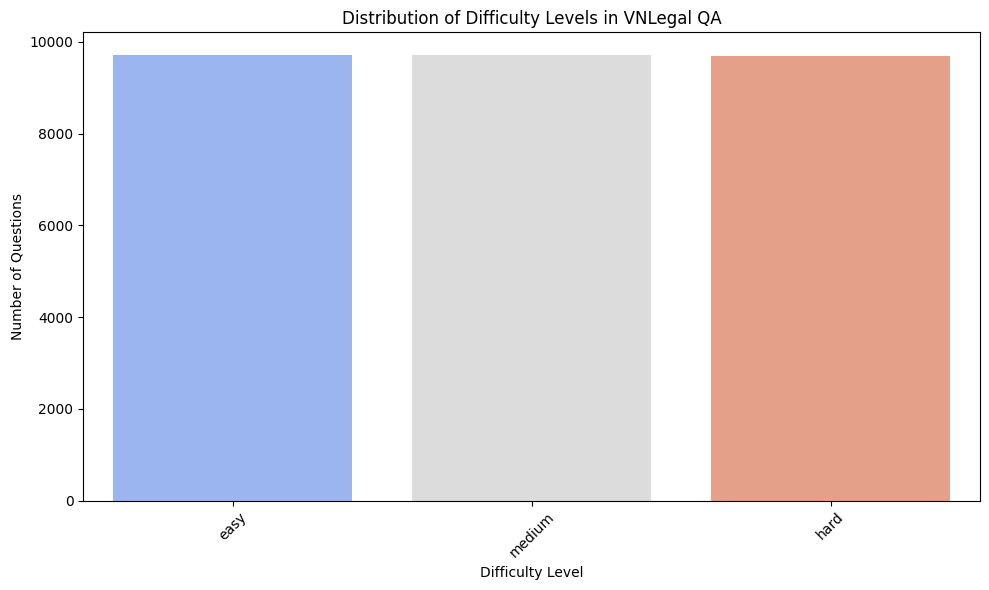

In [42]:
# Distribution of difficulty levels
difficulty_counts = qa_df["difficulty"].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=difficulty_counts.index, y=difficulty_counts.values, palette="coolwarm")
plt.title("Distribution of Difficulty Levels in VNLegal QA")
plt.xlabel("Difficulty Level")
plt.ylabel("Number of Questions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Correlation

In [ ]:
# macro_domain x difficulty
pd.crosstab(qa_df["macro_domain"], qa_df["difficulty"])

difficulty,easy,hard,medium
macro_domain,,,
Civil & Investment,551,551,551
Finance & Banking,2327,2327,2327
"Industry, Resources & Environment",438,435,435
Justice & Dispute Resolution,1708,1708,1708
Labor & Insurance,869,849,865
Security & Defense,370,370,370
State Organization & Admin,1900,1901,1902
Transportation,1561,1561,1561


In [ ]:
# macro_domain x question_type
pd.crosstab(qa_df["macro_domain"], qa_df["question_type"])

question_type,analytical,application,factual,interpretation
macro_domain,,,,
Civil & Investment,298,431,552,372
Finance & Banking,1240,1811,2327,1603
"Industry, Resources & Environment",262,316,439,291
Justice & Dispute Resolution,880,1371,1711,1162
Labor & Insurance,492,637,882,572
Security & Defense,231,260,370,249
State Organization & Admin,1105,1405,1904,1289
Transportation,927,1292,1562,902


## Length

In [76]:
corpus_df["article_len_char"] = corpus_df["article_content"].apply(len)
corpus_df["article_len_word"] = corpus_df["article_content"].apply(lambda x: len(x.split()))

qa_df["question_len_char"] = qa_df["question"].apply(len)
qa_df["question_len_word"] = qa_df["question"].apply(lambda x: len(x.split()))

qa_df["answer_len_char"] = qa_df["answer"].apply(len)
qa_df["answer_len_word"] = qa_df["answer"].apply(lambda x: len(x.split()))

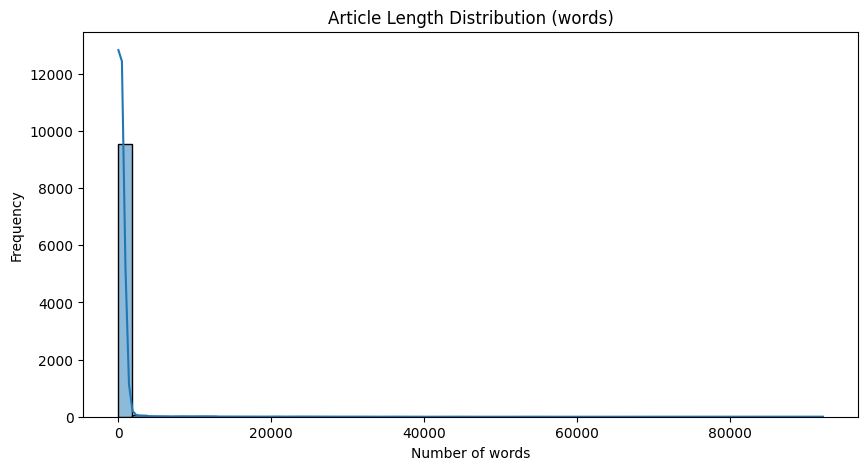

In [77]:
plt.figure(figsize=(10, 5))
sns.histplot(corpus_df["article_len_word"], bins=50, kde=True)
plt.title("Article Length Distribution (words)")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

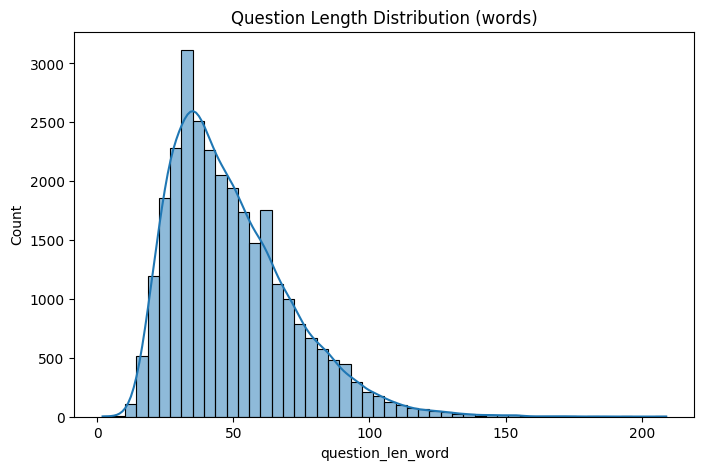

In [78]:
plt.figure(figsize=(8, 5))
sns.histplot(qa_df["question_len_word"], bins=50, kde=True)
plt.title("Question Length Distribution (words)")
plt.show()

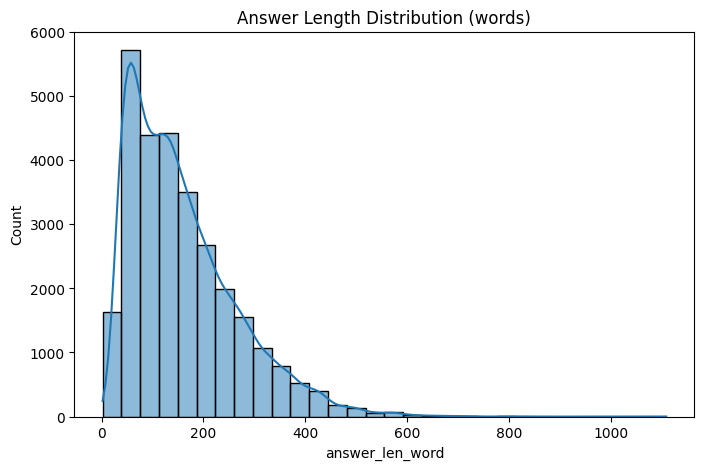

In [79]:
plt.figure(figsize=(8, 5))
sns.histplot(qa_df["answer_len_word"], bins=30, kde=True)
plt.title("Answer Length Distribution (words)")
plt.show()

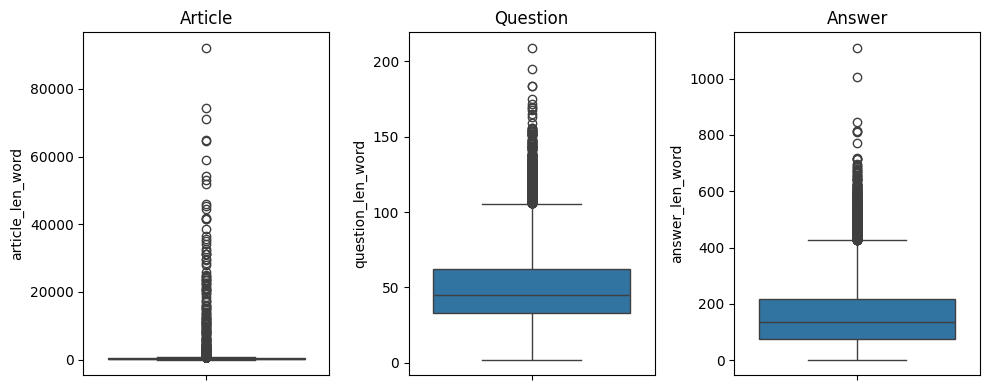

In [80]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
sns.boxplot(y=corpus_df["article_len_word"])
plt.title("Article")

plt.subplot(1, 3, 2)
sns.boxplot(y=qa_df["question_len_word"])
plt.title("Question")

plt.subplot(1, 3, 3)
sns.boxplot(y=qa_df["answer_len_word"])
plt.title("Answer")

plt.tight_layout()
plt.show()

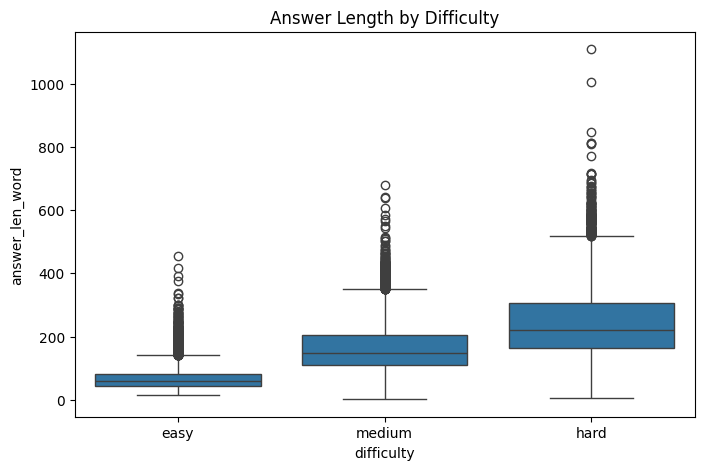

In [81]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="difficulty", y="answer_len_word", data=qa_df)
plt.title("Answer Length by Difficulty")
plt.show()

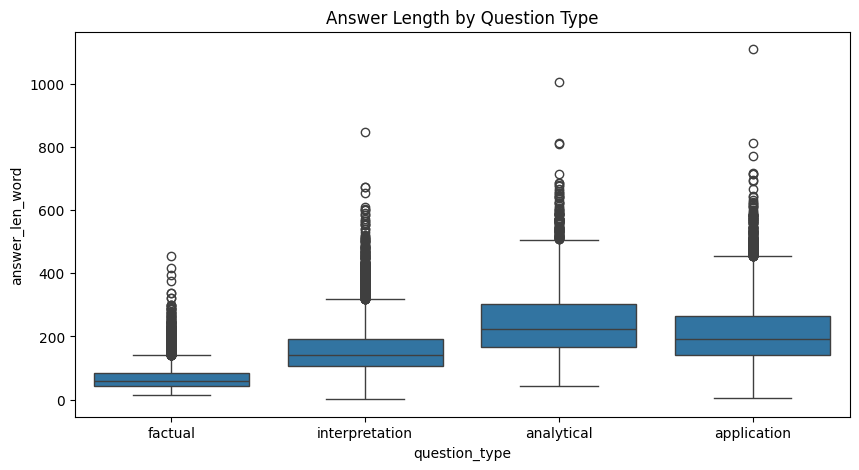

In [82]:
plt.figure(figsize=(10, 5))
sns.boxplot(x="question_type", y="answer_len_word", data=qa_df)
plt.title("Answer Length by Question Type")
plt.show()

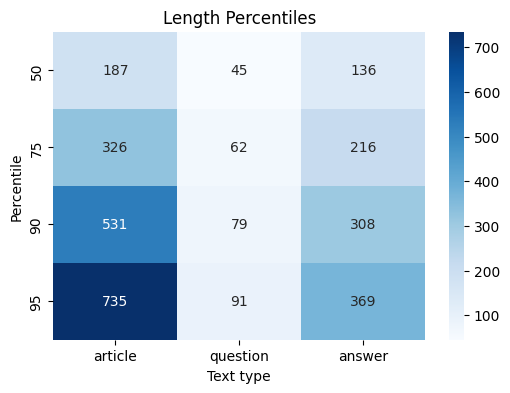

In [86]:
percentiles = [50, 75, 90, 95]

stats_df = pd.DataFrame({
    "article": [np.percentile(corpus_df["article_len_word"], p) for p in percentiles],
    "question": [np.percentile(qa_df["question_len_word"], p) for p in percentiles],
    "answer": [np.percentile(qa_df["answer_len_word"], p) for p in percentiles],
}, index=percentiles)

plt.figure(figsize=(6, 4))
sns.heatmap(stats_df, annot=True, fmt=".0f", cmap="Blues")
plt.title("Length Percentiles")
plt.ylabel("Percentile")
plt.xlabel("Text type")
plt.show()